In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pandas as pd

### load and analyze the dataset

In [2]:
data = fetch_california_housing()
print(data.DESCR)
print(data.feature_names)
print(data.target_names)

#Check the dimensions of the data
x=data.data
print(x.shape)
y=data.target
print(y.shape)

#Put the data in a dataframe for easier visualization
columns=data.feature_names.copy()
df = pd.DataFrame(x, columns=columns)
df['target'] = y
df.head(10)

#get a summary of the data
df.describe()

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


#### print the correlation matrix

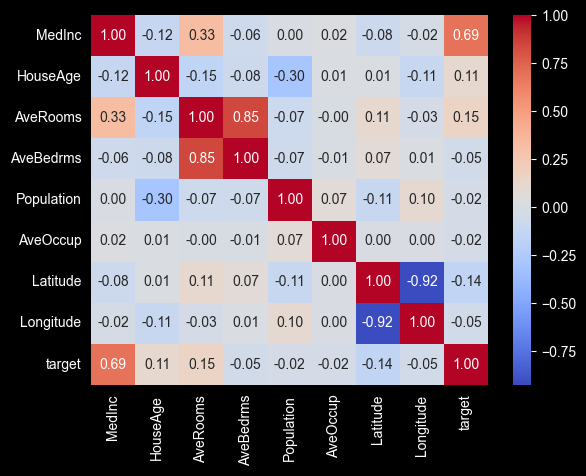

In [3]:
corrM=df.corr()
sns.heatmap(corrM, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

### split the data, fit the model and calculate the feature importance

In [4]:
x=df[columns]
y=df['target']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

# fit the model
model=RFR(n_estimators=100, random_state=42)
model = model.fit(x_train, y_train)

importances=[]
for col, val in zip(columns,model.feature_importances_):
    importances.append((col, val))
importances.sort(key=lambda x: x[1], reverse=True)
print(importances)

[('MedInc', np.float64(0.5224521855007008)), ('AveOccup', np.float64(0.1379665764733086)), ('Latitude', np.float64(0.0906344379866726)), ('Longitude', np.float64(0.08960859227684445)), ('HouseAge', np.float64(0.054168343148216974)), ('AveRooms', np.float64(0.04493439737294255)), ('Population', np.float64(0.03070501149983353)), ('AveBedrms', np.float64(0.029530455741480516))]


#### perform some predictions

In [5]:
predictions=model.predict(x_test)
print("R Squared={:.2f}".format(model.score(x_test, y_test)))

R Squared=0.81


### initialize the SHAP explainer and compute SHAP values for the test set

In [6]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(x_test)
shap.initjs()
print(columns)
print(shap_values.values[0])

#print the average/base value
print("Base Value={:.3f}".format(shap_values.base_values[0]))

#predict the price of the first instance in the test date
print("Predicted Price= {:.3f}".format(model.predict([x_test.iloc[0]])[0]))
print("Actual={:.2f}".format(y_test.iloc[0]))

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
[-0.82969334  0.00282077 -0.01219831 -0.00778918 -0.00170226 -0.24416989
 -0.32283476 -0.14426503]
Base Value=2.070
Predicted Price= 0.510
Actual=0.48


C:\Users\chalo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


#### plot the feature importances

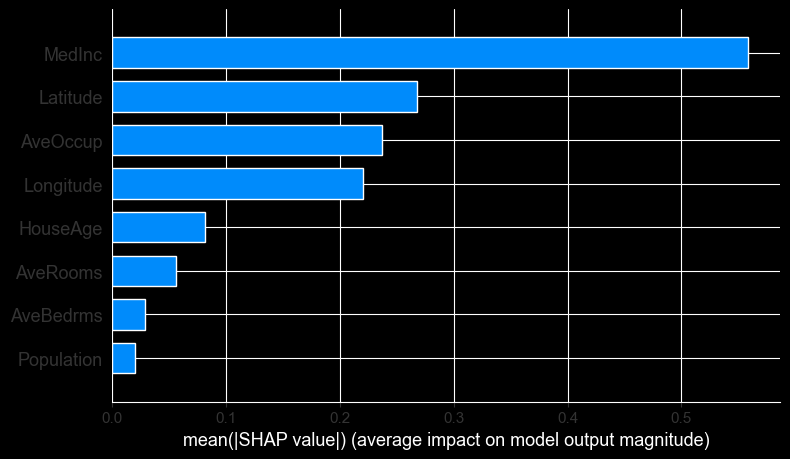

In [7]:
shap.summary_plot(shap_values, x_test, plot_type='bar')

#### create the summary plot

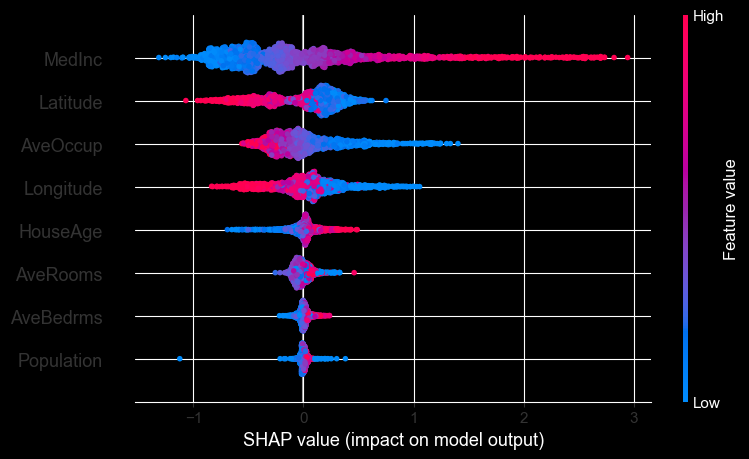

In [8]:
shap.summary_plot(shap_values, x_test)

#### generate the dependence plot of latitude on longitude

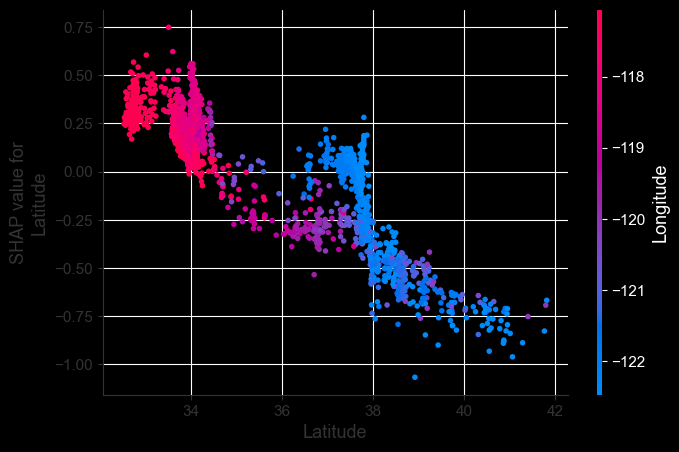

In [9]:
shap.dependence_plot("Latitude", shap_values.values, x_test, interaction_index="Longitude")

#### generate the force plot for the first instance in the test set

In [10]:
shap.force_plot(explainer.expected_value,shap_values.values[0,:], x_test.iloc[0,:])